In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import warnings
import numba
import seaborn as sns
import random
import scipy

sc.set_figure_params(dpi=80)
plt.rcParams["axes.grid"] = False

import matplotlib
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

%config InlineBackend.figure_format='retina'


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))
thresholding_functions = lazy_import("thresholding_functions",os.path.join(utils_dir, "thresholding_functions.py"))
gene_signatures_utils = lazy_import("gene_signatures_utils",os.path.join(utils_dir, "gene_signatures.py"))
preprocessing_utils = lazy_import("preprocessing_utils",os.path.join(utils_dir, "preprocessing_utils.py"))
diffusion_maps = lazy_import("diffusion_maps",os.path.join(utils_dir, "diffusion_maps.py"))

from general_utils import ismember, grep
from plotting_functions import plot_individual_category, plot_scatter, plot_signature, plot_gene, get_pseudo_colors, pseudo_color, make_density_map
from anndata_utils import marker_genes_for_cell_group, zscore_with_subset, get_gene, get_genes, annotate_groups
from thresholding_functions import threshold_otsu, threshold_triangle, histogram_knee
from gene_signatures_utils import toupper, attach_selected_signatures
from preprocessing_utils import norm_log_transform, HVG_selection, kneepoint, process_pca_results, process_pca_inflection
from diffusion_maps import get_diffusion_operator_from_knn, getDiffusionComponents, plot_diffusion_components, imputeData


#### Generate embeddings

Load integrated data and define parameters

In [ ]:
adata = sc.read_h5ad("../data/Reyes_Krasi_SUBSET_all__integrated.h5ad")
adata = adata[np.logical_not(ismember(adata.obs['hash_id'], ['Negative', 'undefined'])[1]),:].copy()

num_HVG = 3000
pca_mode = 'inflection'
layer = 'cellbender'
norm_strategy = 'noExcluded'

In [ ]:
adata.obs['size_factor'] = np.exp(np.ravel(adata.obs['log_lib_size_%s_%s' % (layer, norm_strategy)]))

Embed samples

In [ ]:
adata_sub = adata.copy()
adata_sub.X = adata_sub.layers[layer].copy()
adata_sub = norm_log_transform(adata_sub, adata_sub.obs['size_factor'], [])

sc.pp.filter_cells(adata_sub, min_counts=1)
sc.pp.filter_genes(adata_sub, min_cells=1)

adata_sub = HVG_selection(adata_sub, num_HVG = num_HVG, exclude_genes = adata_sub.var['excluded'], mode = 'scanpy', layer=layer)
sc.pp.pca(adata_sub, n_comps=200, use_highly_variable=True)

Normalizing data
Log transform with pseudocount 1
Highly variable gene selection with custom gene exclusion
Selecting 3000 highly variable genes using Scanpy Seurat v3
Using 3000 highly variable genes


Detecting inflection point with average smoothing window of 10 and epsilon 0.000010


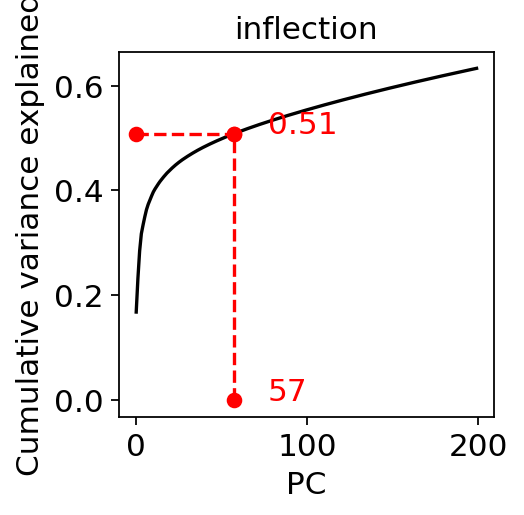

In [ ]:
selected_pcs, explained_var = process_pca_results(adata_sub, pca_mode = pca_mode, epsilon = 0.00001)
adata_sub.obsm['X_pca'] = adata_sub.obsm['X_pca'][:,:selected_pcs].copy()

In [ ]:
sc.pp.neighbors(adata_sub, n_neighbors=30)
sc.tl.umap(adata_sub)
communities = sc.external.tl.phenograph(adata_sub, k=30, clustering_algo = 'leiden', seed = 0, copy=True)
adata_sub.obs['pheno_30'] = pd.Categorical(communities[0])
communities = sc.external.tl.phenograph(adata_sub, k=10, clustering_algo = 'leiden', seed = 0, copy=True)
adata_sub.obs['pheno_10'] = pd.Categorical(communities[0])

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.5016038417816162 seconds
Jaccard graph constructed in 9.116744995117188 seconds
Running Leiden optimization
Leiden completed in 1.0104577541351318 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 31.33445382118225 seconds
Finding 10 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.44620633125305176 seconds
Jaccard graph constructed in 6.816784620285034 seconds
Running Leiden optimization
Leiden completed in 0.6591067314147949 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 13.156027555465698 seconds


/data/lowe/reyesj3/miniconda3/envs/rpy2_milo/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


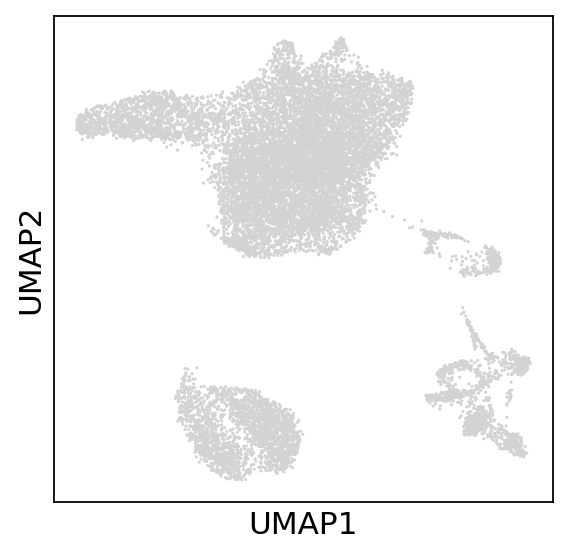

In [ ]:
sc.pl.umap(adata_sub)

Force directed llayout computation

In [ ]:
sc.tl.draw_graph(adata_sub, init_pos="X_umap")

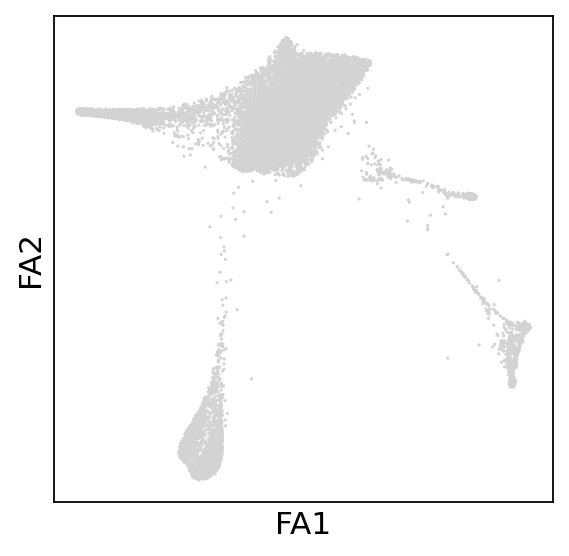

In [ ]:
sc.pl.draw_graph(adata_sub)

### Annotate cell types

In [ ]:
adata_sub.obs['pheno_10'] = pd.Categorical(adata_sub.obs['pheno_10'])

/data/lowe/reyesj3/miniconda3/envs/rpy2_milo/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


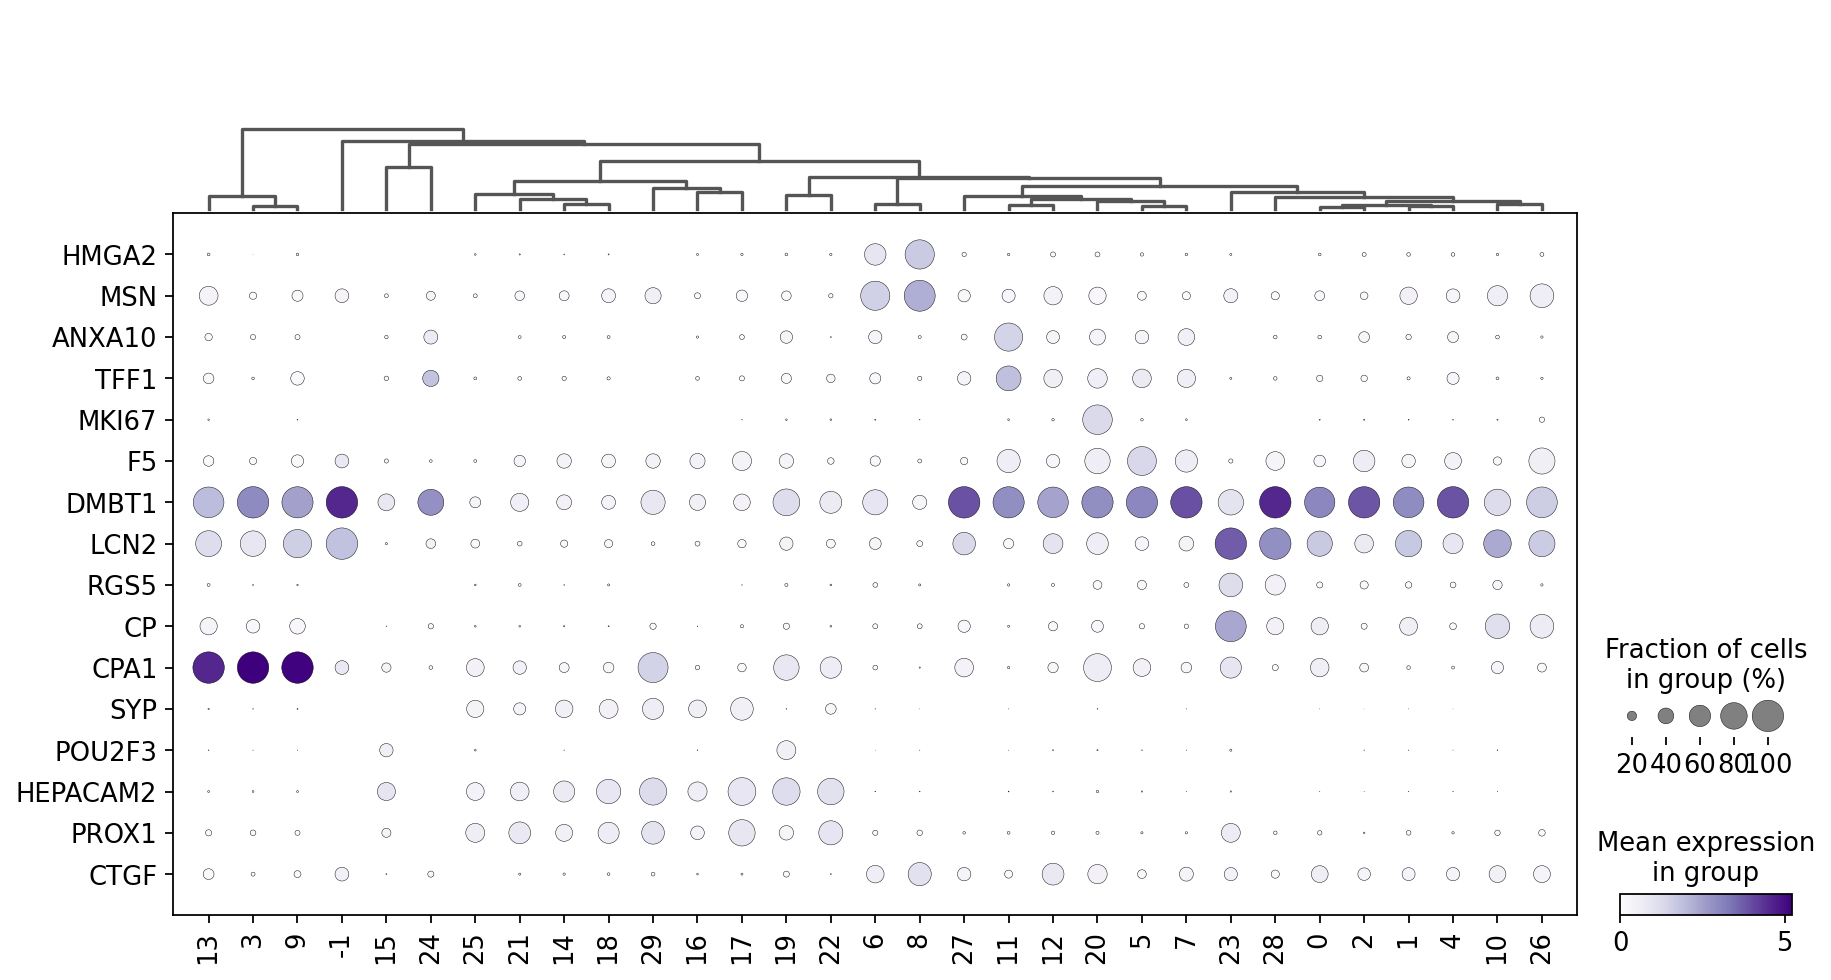

In [ ]:
selected_genes = ['HMGA2', 'MSN', 'ANXA10', 'TFF1', 'MKI67', 'F5', 'DMBT1', 'LCN2', 'RGS5', 'CP', 'CPA1', 'SYP', 'POU2F3', 'HEPACAM2', 'PROX1', 'CTGF']
sc.tl.dendrogram(adata_sub, groupby = 'pheno_10', var_names = selected_genes)
sc.pl.dotplot(adata_sub, groupby='pheno_10', var_names=selected_genes, swap_axes = True, dendrogram=True, cmap = "Purples")

In [ ]:
cell_type = np.array(['gastric'] * adata_sub.n_obs, dtype = object)
cell_type[ismember(adata_sub.obs['pheno_10'], [6,8])[1]] = 'progenitor'
cell_type[ismember(adata_sub.obs['pheno_10'], [13,3,9])[1]] = 'adm'
cell_type[ismember(adata_sub.obs['pheno_10'], [15,19])[1]] = 'tuft'
cell_type[ismember(adata_sub.obs['pheno_10'], [25,21,14,18,29,16,17,22])[1]] = 'neuroendocrine'
cell_type[ismember(adata_sub.obs['pheno_10'], [23])[1]] = 'duct'
cell_type[ismember(adata_sub.obs['pheno_10'], [20])[1]] = 'cycling'
cell_type[ismember(adata_sub.obs['pheno_10'], [5])[1]] = 'gastric_chief'
cell_type[ismember(adata_sub.obs['pheno_10'], [11,24])[1]] = 'gastric_pit'
adata_sub.obs['cell_type'] = cell_type.copy()

#### Save final matrix

In [ ]:
outputFile = "../data/Reyes_Krasi_SUBSET_all__annotated.h5ad"
if not os.path.exists(outputFile):
    sc.write(filename = outputFile, adata = adata_sub)


#### Plot conditions and cell_types

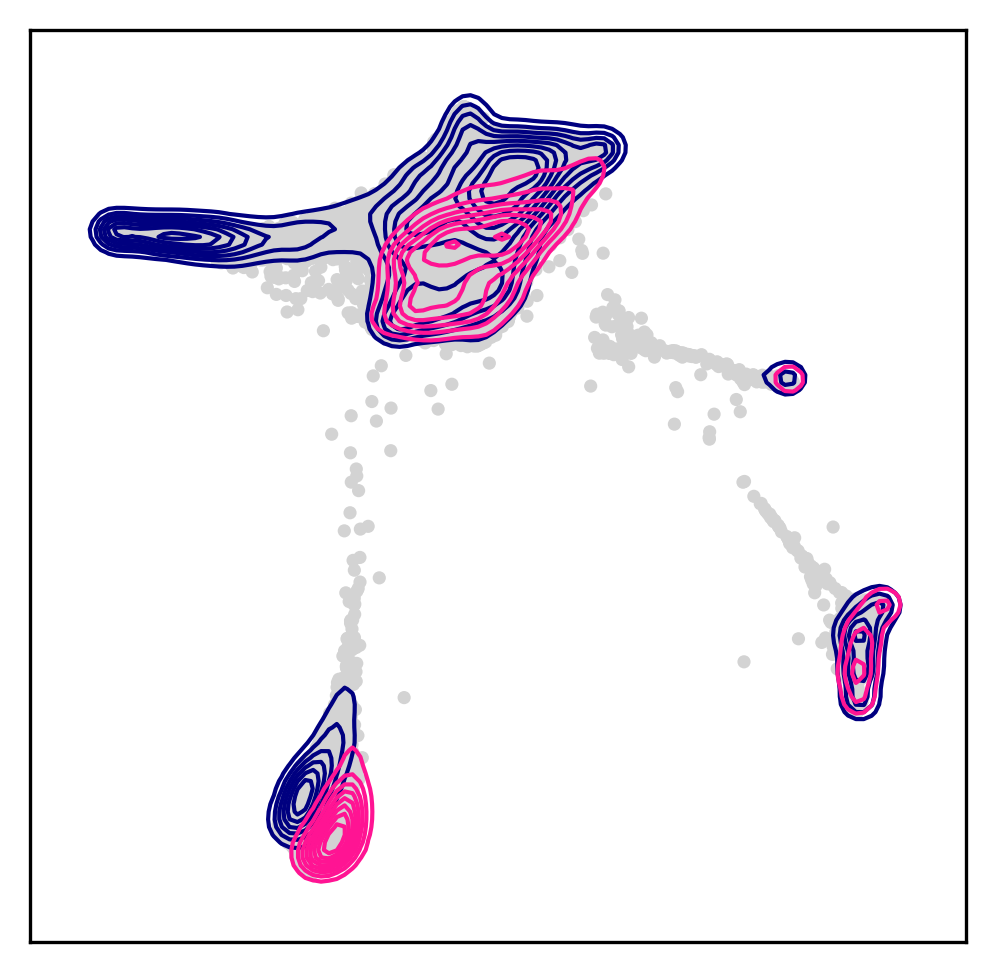

In [ ]:
ax = plot_individual_category(
    adata_sub, "X_draw_graph_fa", "cell_type", [], [], background_color='white', 
    s = 0.5, figsize_max=4, use_outlines=False, axes_color='white')

xval = adata_sub.obsm['X_draw_graph_fa'][:,0]
yval = adata_sub.obsm['X_draw_graph_fa'][:,1]
plt.scatter(xval, yval, edgecolor = 'None', facecolor = 'lightgray', marker='o', s = 10, alpha = 1, rasterized = True)

num_contours = 10
x_, y_, z_grid = make_density_map(adata_sub, adata_sub.obs['condition'] == 'K2Vehicle', "X_draw_graph_fa", num_contours, "navy", background_color = None, gaussian_sigma = 1.5)
x_, y_, z_grid = make_density_map(adata_sub, adata_sub.obs['condition'] == 'K2MRTX1133', "X_draw_graph_fa", num_contours, "deeppink", background_color = None, gaussian_sigma = 1.5)


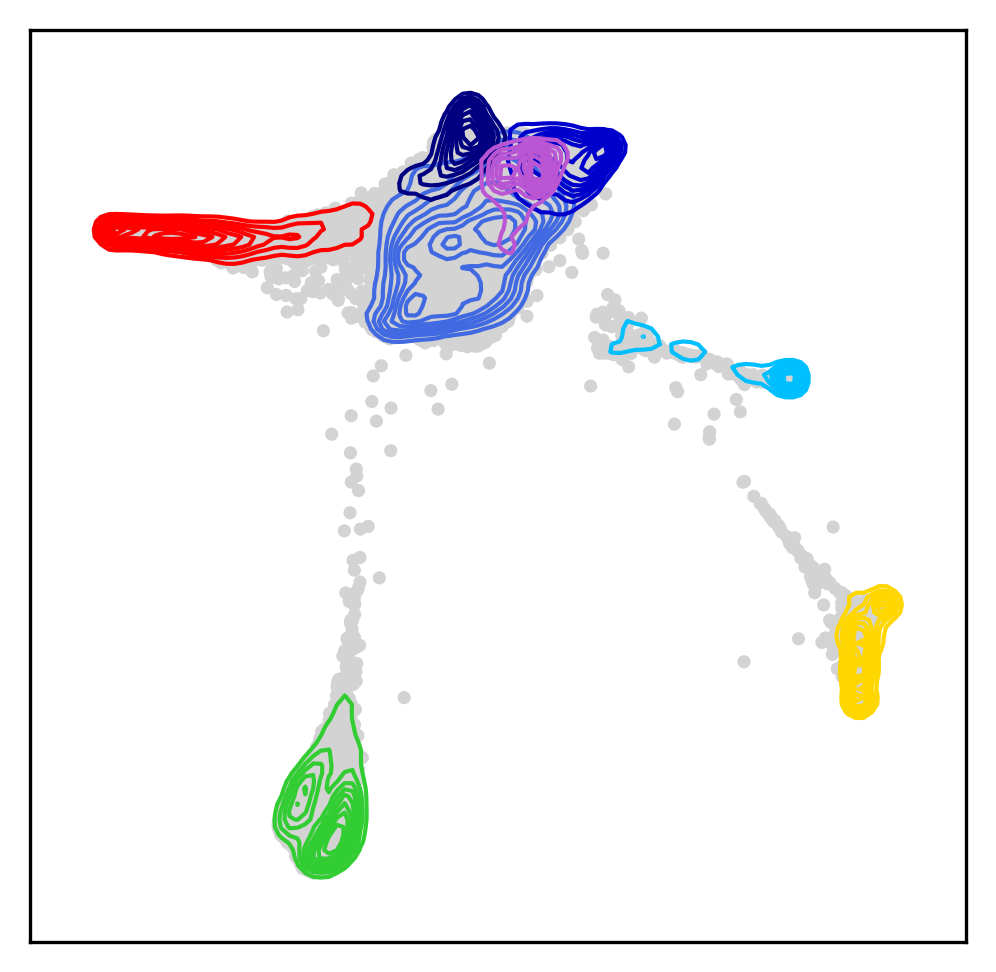

In [ ]:
ax = plot_individual_category(
    adata_sub, "X_draw_graph_fa", "cell_type", [], [], background_color='white', 
    s = 0.5, figsize_max=4, use_outlines=False, axes_color='white')

xval = adata_sub.obsm['X_draw_graph_fa'][:,0]
yval = adata_sub.obsm['X_draw_graph_fa'][:,1]
plt.scatter(xval, yval, edgecolor = 'None', facecolor = 'lightgray', marker='o', s = 10, alpha = 1, rasterized = True)

num_contours = 10
x_, y_, z_grid = make_density_map(adata_sub, adata_sub.obs['cell_type'] == 'progenitor', "X_draw_graph_fa", num_contours, "red", background_color = None, gaussian_sigma = 1)
x_, y_, z_grid = make_density_map(adata_sub, adata_sub.obs['cell_type'] == 'gastric', "X_draw_graph_fa", num_contours, "royalblue", background_color = None, gaussian_sigma = 1)
x_, y_, z_grid = make_density_map(adata_sub, adata_sub.obs['cell_type'] == 'gastric_pit', "X_draw_graph_fa", num_contours, "navy", background_color = None, gaussian_sigma = 1)
x_, y_, z_grid = make_density_map(adata_sub, adata_sub.obs['cell_type'] == 'gastric_chief', "X_draw_graph_fa", num_contours, "mediumblue", background_color = None, gaussian_sigma = 1)
x_, y_, z_grid = make_density_map(adata_sub, adata_sub.obs['cell_type'] == 'tuft', "X_draw_graph_fa", num_contours, "deepskyblue", background_color = None, gaussian_sigma = 1)
x_, y_, z_grid = make_density_map(adata_sub, adata_sub.obs['cell_type'] == 'cycling', "X_draw_graph_fa", num_contours, "mediumorchid", background_color = None, gaussian_sigma = 1)
x_, y_, z_grid = make_density_map(adata_sub, adata_sub.obs['cell_type'] == 'neuroendocrine', "X_draw_graph_fa", num_contours, "gold", background_color = None, gaussian_sigma = 1)
x_, y_, z_grid = make_density_map(adata_sub, adata_sub.obs['cell_type'] == 'adm', "X_draw_graph_fa", num_contours, "limegreen", background_color = None, gaussian_sigma = 1)


#### Milo

In [ ]:
outputFile = "../data/Reyes_Krasi_SUBSET_all__annotated.h5ad"
adata_sub = sc.read_h5ad(outputFile)
adata_sub.obs['replicate_id'] = [x + '_' + y for x,y in zip(adata_sub.obs['condition'], adata_sub.obs['hash_id'])]

In [ ]:
import rpy2
from rpy2.robjects import pandas2ri
import rpy2.robjects as robjects

def read_R_data_frame(r_command):
    my_data_frame = robjects.r(r_command)
    df = pd.DataFrame.from_dict({ key : np.asarray(my_data_frame.rx2(key)) for key in my_data_frame.names })
    return(df)

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
sources, targets = adata_sub.obsp['distances'].nonzero()
X_pca = adata_sub.obsm["X_pca"].copy()
obs_names = adata_sub.obs_names.to_numpy()
obs = adata_sub.obs.copy()

milo_output_file = re.sub("annotated.h5ad", "milo.RData", outputFile)


In [ ]:
%%R -i X_pca,obs,obs_names,sources,targets,milo_output_file

library(miloR)
library(Matrix)
library(SingleCellExperiment)

force = TRUE
set.seed(222)

if(!file.exists(milo_output_file) | force){
    knn_sparse <- sparseMatrix(i=sources + 1, j=targets + 1,x=rep(1, length(sources)))
    precomputed_knn <- buildFromAdjacency(knn_sparse, is.binary=TRUE)
    SCE <- SingleCellExperiment(
        assays=list(counts=Matrix(0L, nrow=1, ncol=nrow(X_pca))),
        reducedDims=SimpleList("PCA"=X_pca)
    )
    milo <- Milo(SCE)
    graph(milo) <- precomputed_knn@graph[[1]]
    milo <- makeNhoods(milo, prop = 0.01, k = 30, d=dim(reducedDim(milo))[2], refined = TRUE, reduced_dims = "PCA")
    milo@.k=30
    milo <- countCells(milo, meta.data = obs, sample="replicate_id")
    milo <- calcNhoodDistance(milo, d=30)
    milo <- buildNhoodGraph(milo)
    save(milo, file = milo_output_file)
}else{
    load(milo_output_file)    
}


/data/lowe/reyesj3/miniconda3/envs/rpy2_milo/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "pheno_30". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/data/lowe/reyesj3/miniconda3/envs/rpy2_milo/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "pheno_10". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
R[write to console]: Loading required package: edgeR

R[write to console]: Loading required package: limma

R[write to console]: Loading required package: SummarizedExperiment

R[write to console]: Loading required package: MatrixGenerics

R[write to console]: Loading required pack

In [ ]:
%%R
design_df <- obs[,c("replicate_id", "condition")]
design_df <- design_df[!duplicated(design_df),]
rownames(design_df) <- design_df$replicate_id
design_df

da_results <- testNhoods(milo, design = ~ condition, design.df = design_df)

R[write to console]: Using TMM normalisation

R[write to console]: Performing spatial FDR correction withk-distance weighting



In [ ]:
%%R
library(anndata)
adata <- AnnData(X = nhoods(milo))
adata$obs_names <- obs_names
adata$var <- da_results
adata$obs <- obs
write_h5ad(adata, gsub(".RData", ".h5ad", milo_output_file))


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

Bring back Milo results into python

In [ ]:
def most_common(v):
    values, counts = np.unique(v, return_counts=True)
    ind = np.argmax(counts)
    return(values[ind])  # prints the most frequent element
    

In [ ]:
adata_milo = sc.read_h5ad(re.sub(".RData", ".h5ad", milo_output_file))

In [ ]:
sources, targets = adata_milo.X.nonzero()
df = pd.DataFrame({'nhood': targets, 'cell_id': sources})
df['cell_type'] = adata_milo.obs['cell_type'].to_numpy()[df['cell_id'].to_numpy()]
df['pheno'] = adata_milo.obs['pheno_30'].to_numpy()[df['cell_id'].to_numpy()]

adata_milo.var['cell_type'] = df.groupby('nhood').agg(lambda x: most_common(x))['cell_type'].to_numpy()
adata_milo.var['pheno'] = df.groupby('nhood').agg(lambda x: most_common(x))['pheno'].to_numpy()

df = adata_milo.var.copy()

In [ ]:
cell_type_order = df.loc[:,['logFC', 'cell_type']].groupby('cell_type').agg(lambda x: np.mean(x)).sort_values(by = 'logFC')
df['ordering'] = ismember(df['cell_type'], cell_type_order.index.to_numpy())[0]

In [ ]:
color_code = {
    'tuft': 'deepskyblue',
    'adm': 'limegreen',
    'progenitor': 'red',
    'gastric': 'royalblue',
    'cycling': 'mediumorchid',
    'gastric_chief': 'mediumblue',
    'gastric_pit': 'navy',
    'neuroendocrine': 'gold',
    'duct': 'green'
}
df['point_size'] = -np.log(df['SpatialFDR'])/np.log(10) * 20
df['randomness'] = [np.random.rand() * 0.25 for x in range(df.shape[0])]
df['xval'] = df['ordering'] + df['randomness']
df['color'] = [color_code[x] for x in df['cell_type']]

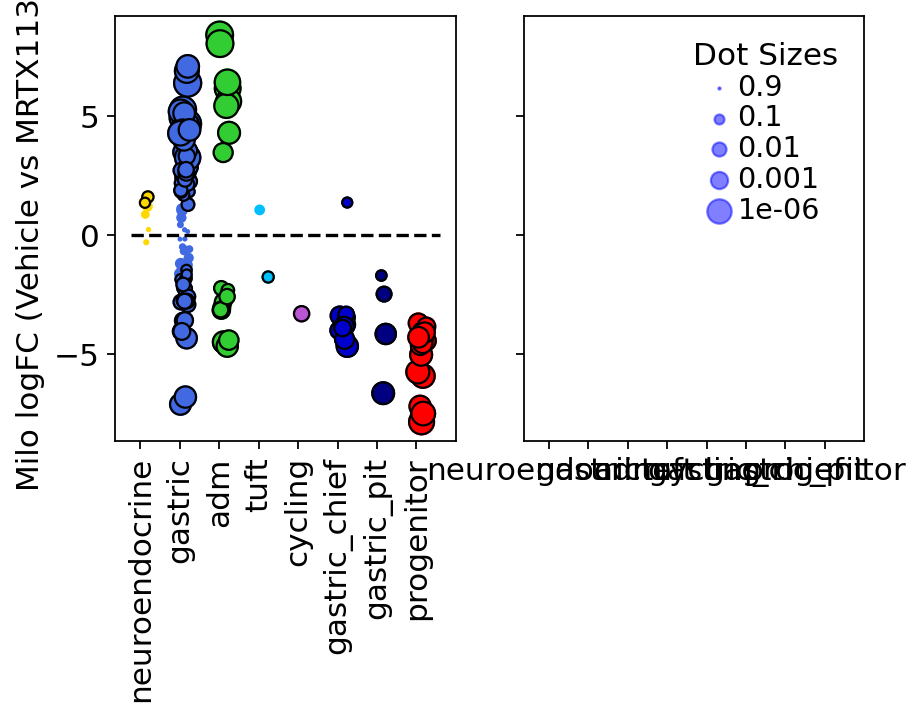

In [ ]:
f, ax = plt.subplots(1,2,figsize = [6,3.5], sharex = True, sharey = True)
ax[0].scatter(df['xval'], -df['logFC'], s = df['point_size'], facecolor=df['color'].to_numpy())
sub_neighborhoods = df['SpatialFDR'] < 0.1
ax[0].scatter(
    df['xval'][sub_neighborhoods], 
    -df['logFC'][sub_neighborhoods], 
    s = df['point_size'][sub_neighborhoods], 
    edgecolor='k', 
    facecolor = df['color'].to_numpy()[sub_neighborhoods])
ax[0].grid(False)
ax[0].plot(ax[0].get_xlim(), [0,0], 'k--')
_ = ax[0].set_xticks(range(cell_type_order.shape[0]), labels=cell_type_order.index.to_numpy(), rotation = 90)
ax[0].set_ylabel('Milo logFC (Vehicle vs MRTX1133)')

labels = [0.9, 0.1, 0.01, 0.001, 0.000001]
sizes = [-np.log(x)/np.log(10) * 20 for x in labels]

# Create the scatter plot - we plot empty data, just to generate legend handles
for size, label in zip(sizes, labels):
    ax[1].scatter([], [], s=size, label=label, color='blue', alpha=0.5)

# Create legend with size-based handles
ax[1].legend(scatterpoints=1, frameon=False, labelspacing=0.1, title='Dot Sizes')